In [1]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 28.3 MB/s  0:00:00m0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 51.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]2m1/2 [gensim]
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 42.6 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 90.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 26.8 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 5.9 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 33.6 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 69.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 38.9 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 53.2 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 43.7 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 44.4 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.

In [7]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [8]:
# ============================================================================
# IMPORTS
# ============================================================================
from lxml import etree
import pandas as pd
import os
from IPython.display import clear_output
from tqdm import tqdm
from shutil import copyfile
import datetime
import re
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Installation des packages si nécessaire
# !pip install lxml tqdm gensim nltk

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
nltk.download('stopwords')

from gensim import corpora, models
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================================
# CONFIGURATION
# ============================================================================
namespaces = {'ns': 'http://schemas.assemblee-nationale.fr/referentiel'}

# Racines de mots pour capturer toutes les déclinaisons
a_tester = [
    "viol ", "sexis", "sexuel", "conjugal", "féminicide", "harcèl",
    "inceste", "outrage", "misogyn",
    "sexe", "genre", "pédocrim", "pédophil", "prostitu",
    "proxénét", "mutilation", "mariage forcé",
    "ivg", "avortement",
    "discrimination", "stéréotype", "cybersexis", "revenge porn",
    "me too", "metoo", "balancetonporc", "consentement"
]

seuil = 3  # Nombre de termes minimum pour garder un texte

# ============================================================================
# FONCTIONS DE TRI DES SÉANCES 
# ============================================================================

def tri_titres(fichier, liste):
    """
    Teste si un fichier de débats contient un titre spécifique dans son sommaire.
    
    input : chemin complet du fichier .xml et liste de chaînes de caractères
    output : booléen True si le sommaire comprend une des expressions
    """
    try:
        tree = etree.parse(fichier)
        root = tree.getroot()
        
        # Parcourir tous les intitulés de sommaire (niveau 1 et 2)
        for chaine in liste:
            chaine_lower = chaine.lower()
            
            # Sommaire niveau 1
            for titre1 in root.xpath('//ns:sommaire1//ns:intitule', namespaces=namespaces):
                if titre1.text and chaine_lower in titre1.text.lower():
                    return True
            
            # Sommaire niveau 2
            for titre2 in root.xpath('//ns:sommaire2//ns:intitule', namespaces=namespaces):
                if titre2.text and chaine_lower in titre2.text.lower():
                    return True
        
        return False
    
    except Exception as e:
        print(f"Erreur dans tri_titres pour {fichier}: {e}")
        return False


def tri_textes(fichier, liste, seuil):
    """
    Teste si un fichier contient un certain nombre d'expressions dans le texte.
    
    input : chemin complet du fichier .xml, liste de chaînes, seuil d'occurrences
    output : booléen True si le texte comprend >= seuil occurrences
    """
    try:
        tree = etree.parse(fichier)
        root = tree.getroot()
        
        nb_occurences = 0
        
        # Récupérer tous les paragraphes
        for para in root.xpath('//ns:paragraphe', namespaces=namespaces):
            # Récupérer tout le texte du paragraphe
            text_nodes = para.xpath('.//ns:texte//text()', namespaces=namespaces)
            texte_complet = " ".join(text_nodes).lower()
            
            # Compter les occurrences de chaque mot-clé
            for chaine in liste:
                # Utiliser regex avec \b pour éviter les faux positifs
                pattern = rf'\b{re.escape(chaine.lower())}'
                matches = len(re.findall(pattern, texte_complet))
                nb_occurences += matches
        
        return nb_occurences >= seuil
    
    except Exception as e:
        print(f"Erreur dans tri_textes pour {fichier}: {e}")
        return False

# ============================================================================
# SÉLECTION DES SÉANCES PERTINENTES
# ============================================================================

def selectionner_seances(dossiers_legislatures, liste_mots, seuil_occurences):
    """
    Parcourt les dossiers des législatures et sélectionne les séances pertinentes.
    
    input : dict {nom_legislature: chemin_dossier}, liste de mots-clés, seuil
    output : liste des noms de fichiers pertinents
    """
    liste_pertinente = []
    
    for legislature, chemin_dossier in dossiers_legislatures.items():
        if not os.path.exists(chemin_dossier):
            print(f"⚠️ Dossier inexistant : {chemin_dossier}")
            continue
        
        fichiers_xml = [f for f in os.listdir(chemin_dossier) if f.endswith('.xml')]
        
        print(f"📂 Analyse de {legislature} : {len(fichiers_xml)} fichiers")
        
        for fichier in tqdm(fichiers_xml, desc=legislature):
            chemin_complet = os.path.join(chemin_dossier, fichier)
            
            # Test sur les titres
            if tri_titres(chemin_complet, liste_mots):
                liste_pertinente.append(fichier)
                continue
            
            # Test sur les textes
            if tri_textes(chemin_complet, liste_mots, seuil_occurences):
                liste_pertinente.append(fichier)
    
    # Enlever les doublons
    liste_pertinente = list(set(liste_pertinente))
    print(f"\n✅ Total : {len(liste_pertinente)} séances retenues")
    
    return liste_pertinente

# ============================================================================
# PARSING DES DÉBATS (CORRIGÉ)
# ============================================================================

def parsing_debats(fichier):
    """
    Parse un fichier .xml de débats et crée un dataframe des prises de parole.
    
    input : chemin complet du fichier .xml
    output : DataFrame pandas
    """
    try:
        tree = etree.parse(fichier)
        root = tree.getroot()
        
        # Liste pour stocker les données
        data_list = []
        
        # Récupération des métadonnées de la séance
        uid_seance = root.xpath('//ns:uid', namespaces=namespaces)[0].text
        date_brute = root.xpath('//ns:metadonnees/ns:dateSeance', namespaces=namespaces)[0].text[:8]
        date_seance = pd.to_datetime(date_brute)
        legis = root.xpath('//ns:metadonnees/ns:legislature', namespaces=namespaces)[0].text
        
        # Parcourir tous les paragraphes
        for para in root.xpath('//ns:paragraphe', namespaces=namespaces):
            
            # 1. RECHERCHE DE L'ORATEUR
            # D'abord chercher dans le paragraphe lui-même
            nom_interne = para.xpath('./ns:orateurs/ns:orateur/ns:nom/text()', namespaces=namespaces)
            
            if nom_interne:
                nom_orateur = nom_interne[0]
            else:
                # Sinon, chercher le dernier orateur précédent
                nom_precedent = para.xpath('./preceding::ns:orateur[1]/ns:nom/text()', namespaces=namespaces)
                nom_orateur = nom_precedent[0] if nom_precedent else "Inconnu"
            
            # 2. RÉCUPÉRATION DU TEXTE
            text_nodes = para.xpath('.//ns:texte//text()', namespaces=namespaces)
            texte_final = " ".join(text_nodes).replace("\xa0", " ")
            
            # 3. RÉCUPÉRATION DES ATTRIBUTS
            ordre_absolu = para.get("ordre_absolu_seance")
            id_acteur = para.get("id_acteur")
            code_grammaire = para.get("code_grammaire")
            
            # Ajout à la liste
            data_list.append({
                "seanceRef": uid_seance,
                "ordre_absolu_seance": ordre_absolu,
                "date": date_seance,
                "legislature": legis,
                "id_acteur": id_acteur,
                "code_grammaire": code_grammaire,
                "nom_orateur": nom_orateur,
                "texte": texte_final
            })
        
        # Création du DataFrame
        df = pd.DataFrame(data_list)
        
        if not df.empty:
            df["ordre_absolu_seance"] = pd.to_numeric(df["ordre_absolu_seance"], errors='coerce')
            df = df.sort_values(by="ordre_absolu_seance")
        
        return df
    
    except Exception as e:
        print(f"Erreur lors du parsing de {fichier}: {e}")
        return pd.DataFrame()

# ============================================================================
# PARSING DES DÉPUTÉS ET PARTIS
# ============================================================================

def creer_df_partis(dossier_partis):
    """Crée le DataFrame des partis politiques"""
    data_list = []
    
    if not os.path.exists(dossier_partis):
        print(f"⚠️ Dossier partis inexistant : {dossier_partis}")
        return pd.DataFrame(columns=["parti", "nom_parti"])
    
    fichiers = [f for f in os.listdir(dossier_partis) if f.endswith('.xml')]
    
    for fichier in tqdm(fichiers, desc="Parsing partis"):
        chemin = os.path.join(dossier_partis, fichier)
        tree = etree.parse(chemin)
        root = tree.getroot()
        
        uid_parti = root.xpath('//ns:uid', namespaces=namespaces)[0].text
        nom_parti = root.xpath('//ns:libelle', namespaces=namespaces)[0].text
        
        data_list.append({
            "parti": uid_parti,
            "nom_parti": nom_parti
        })
    
    df = pd.DataFrame(data_list)
    df["parti"] = df["parti"].astype(str)
    
    return df


def creer_df_deputes(dossier_deputes):
    """Crée le DataFrame des députés avec leurs affiliations"""
    data_list = []
    
    if not os.path.exists(dossier_deputes):
        print(f"⚠️ Dossier députés inexistant : {dossier_deputes}")
        return pd.DataFrame(columns=["id_acteur", "nom", "prenom", "parti", "debut"])
    
    fichiers = [f for f in os.listdir(dossier_deputes) if f.endswith('.xml')]
    
    for fichier in tqdm(fichiers, desc="Parsing députés"):
        chemin = os.path.join(dossier_deputes, fichier)
        
        try:
            tree = etree.parse(chemin)
            root = tree.getroot()
            
            id_acteur = root.xpath('//ns:uid', namespaces=namespaces)[0].text
            nom = root.xpath('//ns:etatCivil/ns:ident/ns:nom', namespaces=namespaces)[0].text
            prenom = root.xpath('//ns:etatCivil/ns:ident/ns:prenom', namespaces=namespaces)[0].text
            
            # Récupérer tous les mandats de type PARPOL
            for mandat in root.xpath('//ns:mandats/ns:mandat', namespaces=namespaces):
                type_organe = mandat.xpath('./ns:typeOrgane/text()', namespaces=namespaces)
                
                if type_organe and type_organe[0] == "PARPOL":
                    organe_ref = mandat.xpath('./ns:organes/ns:organeRef/text()', namespaces=namespaces)
                    date_debut = mandat.xpath('./ns:dateDebut/text()', namespaces=namespaces)
                    
                    if organe_ref and date_debut:
                        data_list.append({
                            "id_acteur": id_acteur,
                            "nom": nom,
                            "prenom": prenom,
                            "parti": organe_ref[0],
                            "debut": date_debut[0]
                        })
        
        except Exception as e:
            print(f"Erreur sur {fichier}: {e}")
            continue
    
    df = pd.DataFrame(data_list)
    df["parti"] = df["parti"].astype(str)
    df["debut"] = pd.to_datetime(df["debut"], errors='coerce')
    
    return df

# ============================================================================
# AJOUT DES PARTIS DANS LES DÉBATS
# ============================================================================

def ajouter_partis(df_debats, df_deputes):
    """
    Joint un dataframe de séance avec les partis politiques des députés.
    """
    if df_debats.empty:
        return df_debats
    
    # Date de la séance
    date_seance = pd.to_datetime(df_debats.loc[0, "date"])
    
    # Filtrer les députés présents dans cette séance
    concernes = df_deputes[df_deputes["id_acteur"].isin(df_debats["id_acteur"])].copy()
    
    # Forcer la colonne 'debut' en datetime
    concernes["debut"] = pd.to_datetime(concernes["debut"], errors='coerce')
    
    # Garder uniquement les mandats actifs à la date de la séance
    concernes = concernes[concernes["debut"] <= date_seance]
    
    # Garder le mandat le plus récent pour chaque député
    concernes = concernes.sort_values("debut", ascending=False).drop_duplicates(subset="id_acteur", keep="first")
    
    # Merge avec le dataframe des débats
    df_debats = df_debats.merge(
        concernes[["parti", "nom_parti", "id_acteur", "nom", "prenom"]], 
        on="id_acteur", 
        how="left"
    )
    
    return df_debats

# ============================================================================
# TRAITEMENT COMPLET
# ============================================================================

def traiter_toutes_seances(dossiers_legislatures, dossier_sorted, df_deputes, liste_mots):
    """
    Parse toutes les séances pertinentes et crée un DataFrame global.
    """
    all_seances = []
    
    for leg, dossier_source in dossiers_legislatures.items():
        dossier_tri = os.path.join(dossier_sorted, leg.lower())
        
        if not os.path.exists(dossier_tri):
            print(f"⚠️ Dossier trié inexistant : {dossier_tri}")
            continue
        
        fichiers = [f for f in os.listdir(dossier_tri) if f.endswith('.xml')]
        
        for fichier in tqdm(fichiers, desc=f"Parsing {leg}"):
            chemin = os.path.join(dossier_tri, fichier)
            
            try:
                # Parsing du fichier
                df_temp = parsing_debats(chemin)
                
                if df_temp.empty:
                    continue
                
                # Ajout des partis
                df_temp = ajouter_partis(df_temp, df_deputes)
                
                if not df_temp.empty:
                    all_seances.append(df_temp)
            
            except Exception as e:
                print(f"Erreur sur {fichier}: {e}")
                continue
    
    if len(all_seances) > 0:
        df_global = pd.concat(all_seances, ignore_index=True)
        print(f"\n✅ Succès : {len(df_global)} prises de parole récupérées")
        return df_global
    else:
        print("❌ Aucun fichier n'a pu être traité")
        return pd.DataFrame()

# ============================================================================
# FILTRAGE VSS
# ============================================================================

def filtrer_vss(df_global, liste_mots):
    """
    Filtre les prises de parole contenant des mots-clés VSS.
    """
    pattern = '|'.join([re.escape(mot) for mot in liste_mots])
    df_vss = df_global[df_global['texte'].str.contains(pattern, case=False, na=False)].copy()
    
    print(f"📊 {len(df_vss)} prises de parole sur les VSS identifiées")
    
    return df_vss

# ============================================================================
# PRÉ-PROCESSING POUR ANALYSE TEXTUELLE
# ============================================================================

# Configuration des stop words
stop_words_french = stopwords.words('french')
bruit_parlementaire = [
    "loi", "droit", "état", "amend", "articl", "text", "group", "cel", "autr",
    "person", "social", "polit", "publi", "cette", "premier", "monsieur",
    "madame", "président", "ministre", "député", "collègue", "assemblée",
    "proposit", "disposit", "cadre", "mesur", "moyen", "question", "rapport",
    "commission", "gouvern", "souhait", "permettr", "faut", "doit", "peut",
    "bien", "fait", "être", "avoir", "plus", "tout", "tous", "faire",
    "encore", "donc", "vraiment", "toujours"
]
stop_words_french.extend(bruit_parlementaire)

stemmer = FrenchStemmer()

def pre_processing_recherche(texte, stop_words, mots_vss):
    """
    Nettoie le texte, stemme, et retire les mots-clés VSS.
    """
    # Mise en minuscule et retrait de la ponctuation
    texte = re.sub(r'\W+', ' ', str(texte).lower())
    
    # Tokenization
    mots = texte.split()
    
    # Filtrage
    mots_nettoyes = [
        stemmer.stem(m) for m in mots
        if m not in stop_words
        and not any(vss in m for vss in mots_vss)
        and len(m) > 2
    ]
    
    return " ".join(mots_nettoyes)

# ============================================================================
# REGROUPEMENT PAR BLOCS IDÉOLOGIQUES
# ============================================================================

def regrouper_blocs_ideologiques(nom_parti):
    """
    Associe chaque parti à un bloc idéologique.
    """
    nom = str(nom_parti).lower()
    
    # Extrême droite
    if "rassemblement national" in nom or "front national" in nom or "udr" in nom:
        return "Extrême Droite"
    
    # Droite traditionnelle
    if "républicains" in nom:
        return "Droite Traditionnelle"
    
    # Centre
    centre = ["en marche", "république en marche", "renaissance", "ensemble", "modem", "mouvement démocrate", "horizons"]
    if any(c in nom for c in centre):
        return "Centre"
    
    # Gauche modérée
    gauche_m = ["socialiste", "écologistes - eelv", "europe écologie les verts", "radical de gauche"]
    if any(g in nom for g in gauche_m):
        return "Gauche Modérée"
    
    # Gauche radicale
    gauche_r = ["france insoumise", "communiste", "lfi"]
    if any(g in nom for g in gauche_r):
        return "Gauche Radicale"
    
    return None

# ============================================================================
# EXEMPLE D'UTILISATION
# ============================================================================

if __name__ == "__main__":
    
    # Configuration des chemins
    BASE_DIR = "/home/onyxia/work/projet_eco_socio"
    
    dossiers_legislatures = {
        "XV": os.path.join(BASE_DIR, "data/CompteRendusXV/"),
        "XVI": os.path.join(BASE_DIR, "data/CompteRendusXVI/"),
        "XVII": os.path.join(BASE_DIR, "data/CompteRendusXVII/")
    }
    
    dossier_sorted = os.path.join(BASE_DIR, "sorted")
    dossier_partis = os.path.join(BASE_DIR, "partis")
    dossier_deputes = os.path.join(BASE_DIR, "deputes")
    
    # 1. Sélection des séances (si pas déjà fait)
    # liste_pertinente = selectionner_seances(dossiers_legislatures, a_tester, seuil)
    
    # 2. Création des DataFrames de référence
    print("📚 Chargement des partis et députés...")
    df_partis = creer_df_partis(dossier_partis)
    df_deputes = creer_df_deputes(dossier_deputes)
    df_deputes = df_deputes.merge(df_partis, on="parti", how="left")
    
    # 3. Traitement de toutes les séances
    print("\n🔍 Parsing des débats...")
    df_global = traiter_toutes_seances(dossiers_legislatures, dossier_sorted, df_deputes, a_tester)
    
    # 4. Filtrage VSS
    print("\n🎯 Filtrage des prises de parole VSS...")
    df_vss = filtrer_vss(df_global, a_tester)
    
    # 5. Ajout des blocs idéologiques
    df_vss['bloc'] = df_vss['nom_parti'].apply(regrouper_blocs_ideologiques)
    df_vss = df_vss.dropna(subset=['bloc'])
    
    # 6. Nettoyage des textes pour l'analyse
    print("\n🧹 Nettoyage des textes...")
    df_vss['texte_clean'] = df_vss['texte'].apply(
        lambda x: pre_processing_recherche(x, stop_words_french, a_tester)
    )
    
    print("\n✅ Traitement terminé !")
    print(f"📊 Statistiques finales :")
    print(f"   - Prises de parole totales : {len(df_global)}")
    print(f"   - Prises de parole VSS : {len(df_vss)}")
    print(f"   - Blocs représentés : {df_vss['bloc'].nunique()}")

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


📚 Chargement des partis et députés...


Parsing députés: 100%|██████████| 1177/1177 [00:02<00:00, 492.19it/s]



🔍 Parsing des débats...


Parsing XVII: 100%|██████████| 220/220 [00:07<00:00, 30.11it/s]



✅ Succès : 674729 prises de parole récupérées

🎯 Filtrage des prises de parole VSS...
📊 13242 prises de parole sur les VSS identifiées

🧹 Nettoyage des textes...

✅ Traitement terminé !
📊 Statistiques finales :
   - Prises de parole totales : 674729
   - Prises de parole VSS : 10546
   - Blocs représentés : 5


In [10]:
df_vss.sample(1)["texte"].values[0]

'Nous avons une autre conception de la filiation. Il est vrai que nous inventons une nouvelle filiation, à l’égard de la mère qui ne porte pas l’enfant. Nous voulons nous rapprocher le plus possible du mode de filiation qui existe dans le cadre d’un couple hétérosexuel avec la reconnaissance prénatale et à l’état civil.'

In [11]:
print("test")
output_dir = "/home/onyxia/work/projet_eco_socio/analyses_par_partis/"
os.makedirs(output_dir, exist_ok=True)

# on groupe par le nom du parti
for parti, group in df_vss.groupby("nom_parti"):
    # nettoyage du nom du parti pour le nom de fichier
    nom_propre = "".join(x for x in parti if x.isalnum() or x in "._- ").strip()
    
    with open(f"{output_dir}{nom_propre}.txt", "w", encoding="utf-8") as f:
        # on écrit chaque prise de parole dans le fichier
        for discours in group["texte"]:
            f.write(discours + "\n\n---\n\n")

print(f"Documents créés pour {len(df_vss['nom_parti'].unique())} partis.")

test
Documents créés pour 17 partis.


test


/tmp/ipykernel_1216/528758609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vss_counts.values, y=vss_counts.index, palette="viridis")


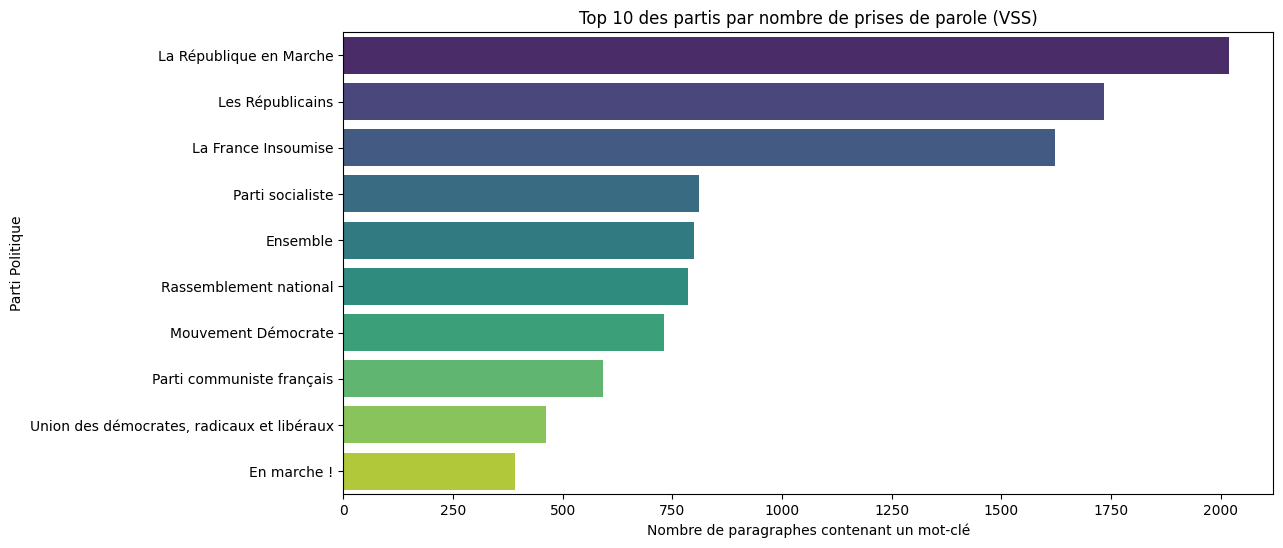

test 2


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("test")
# on s'assure d'avoir notre dataframe filtré avec uniquement les lignes "VSS"
pattern = '|'.join(a_tester)
df_vss = df_global[df_global['texte'].str.contains(pattern, case=False, na=False)].copy()

# Calcul du nombre de prises de parole par parti
vss_counts = df_vss['nom_parti'].value_counts().head(10) # Top 10 des partis

plt.figure(figsize=(12, 6))
sns.barplot(x=vss_counts.values, y=vss_counts.index, palette="viridis")
plt.title("Top 10 des partis par nombre de prises de parole (VSS)")
plt.xlabel("Nombre de paragraphes contenant un mot-clé")
plt.ylabel("Parti Politique")
plt.show()

print("test 2")

/tmp/ipykernel_1216/2531510810.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  evolution = df.resample('M', on='date').size()


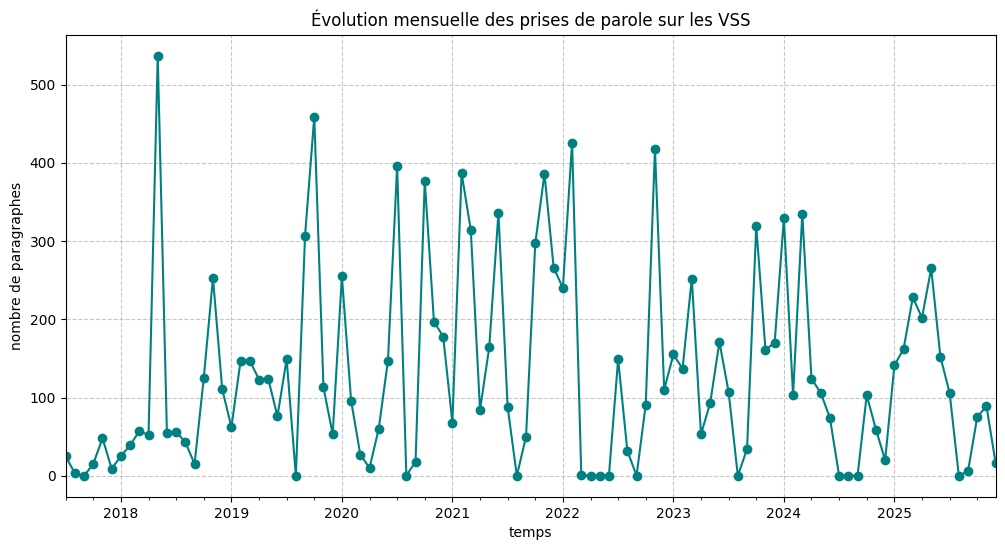

test


In [13]:
def tracer_evolution_vss(df):
    ''' affiche le nombre de prises de parole par mois sur les vss '''
    # on groupe les données par mois et on compte les lignes
    evolution = df.resample('M', on='date').size()
    
    # création du graphique
    plt.figure(figsize=(12, 6))
    evolution.plot(kind='line', marker='o', color='teal')
    plt.title("Évolution mensuelle des prises de parole sur les VSS")
    # on retire la majuscule par habitude ici aussi
    plt.xlabel("temps")
    plt.ylabel("nombre de paragraphes")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

tracer_evolution_vss(df_vss)
print("test")

In [14]:
import torch
from transformers import BertTokenizer, BertModel

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PIPELINE D'ANALYSE VSS – VERSION CAMEMBERT

[1] Calcul des statistiques normalisées...

[2] Génération des graphiques normalisés...


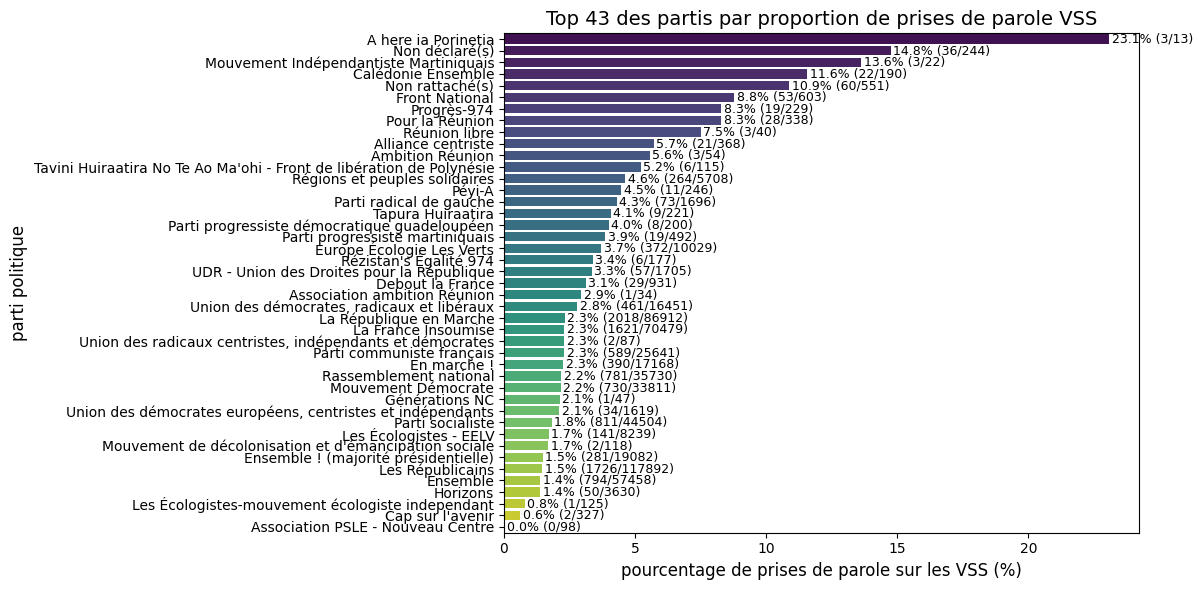

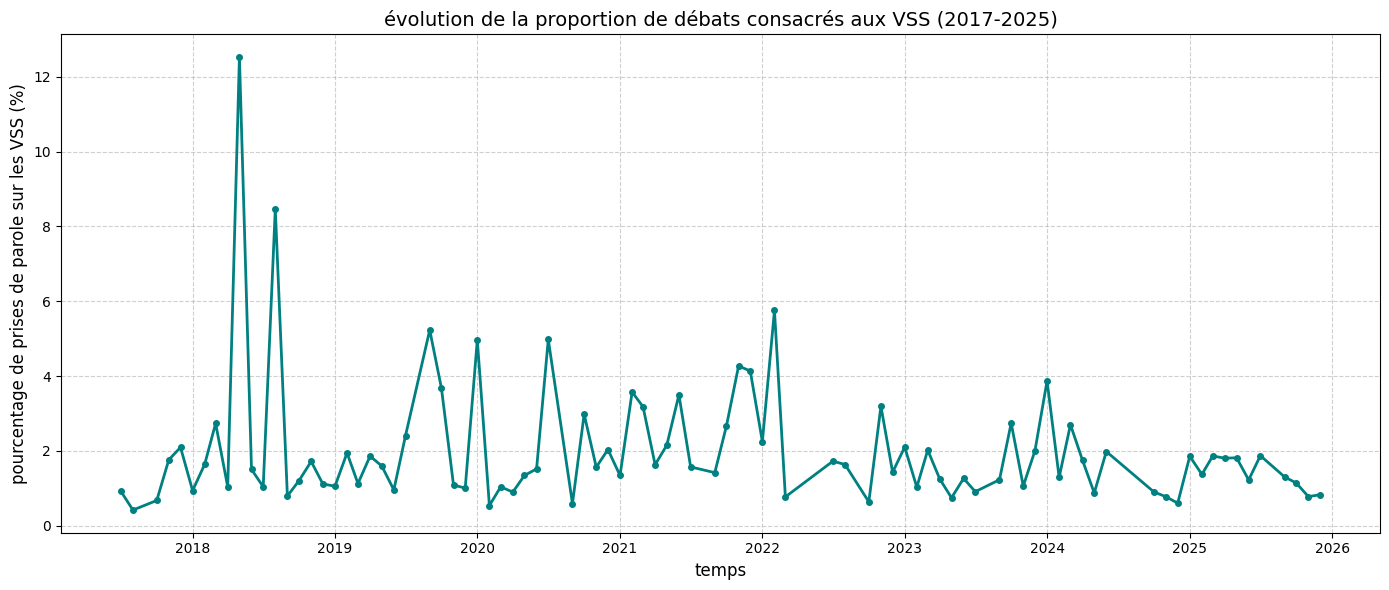

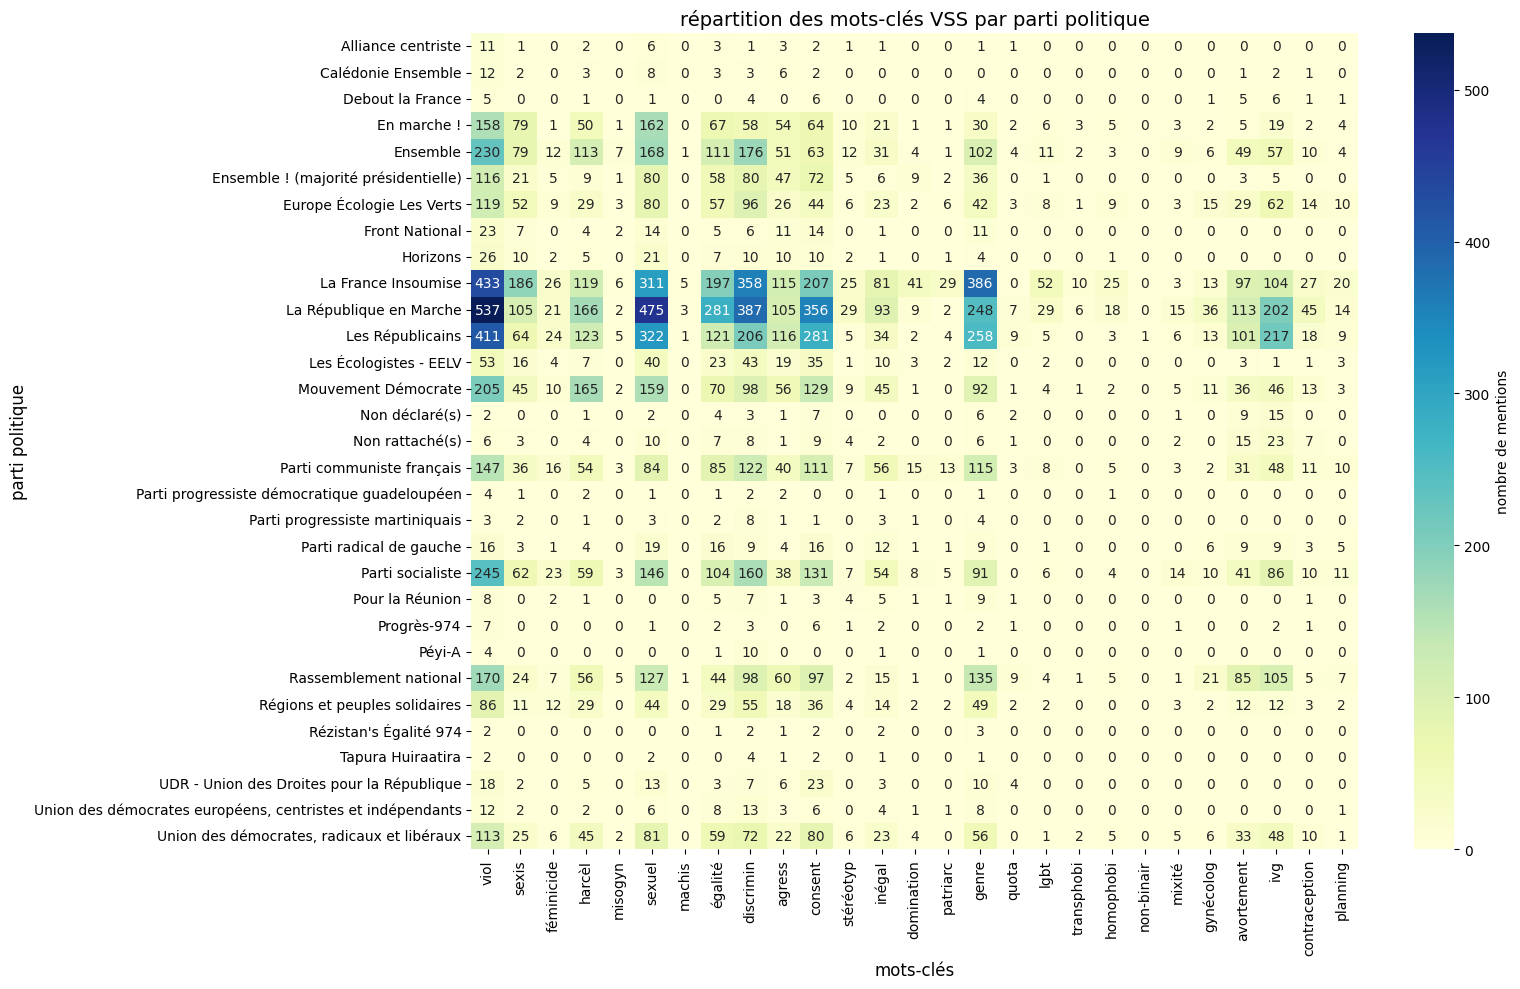


[3] Analyse du cadrage sémantique...
🔍 autour de 'féminicide' chez La France Insoumise : commis, début, parlementaire, hier, appris
🔍 autour de 'féminicide' chez Les Républicains : restera, versement, pensions, réversion, protégerons
🔍 autour de 'féminicide' chez Mouvement Démocrate : violences, conjugales, proposé, retrait, automatique
🔍 autour de 'féminicide' chez La République en Marche : aide, sociale, enfance, victimes, souvent
🔍 autour de 'féminicide' chez Parti socialiste : dernier, suite, commis, marne, associations
🔍 autour de 'féminicide' chez Europe Écologie Les Verts : compagne, mesures, nouvelles, faisons, france
🔍 autour de 'féminicide' chez Régions et peuples solidaires : trentième, appelons, ainsi, victime, 2019
🔍 autour de 'féminicide' chez En marche ! : veut, connaître, hécatombe, conjugale, laisser
🔍 autour de 'féminicide' chez Rassemblement national : loin, catégorie, fourre, conjoint, partenaire
🔍 autour de 'féminicide' chez Parti communiste français : seine, sain

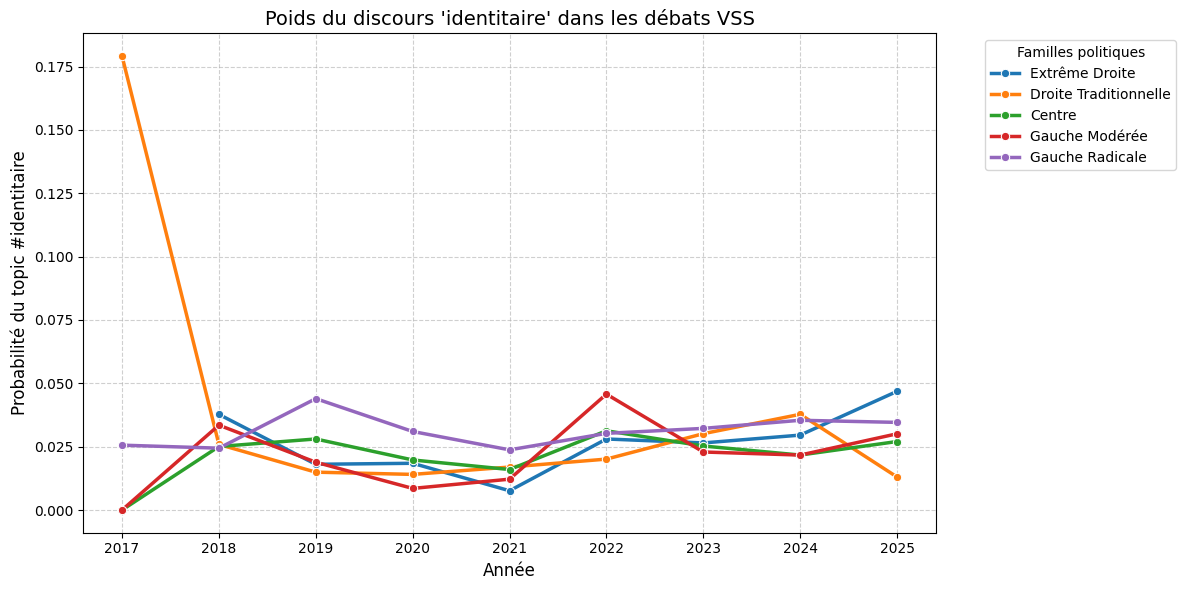


[8] Chargement de CamemBERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 655.55it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encodage des prises de parole individuelles (ça va prendre un peu de temps)...


Encodage CamemBERT: 100%|██████████| 10509/10509 [38:49<00:00,  4.51it/s]


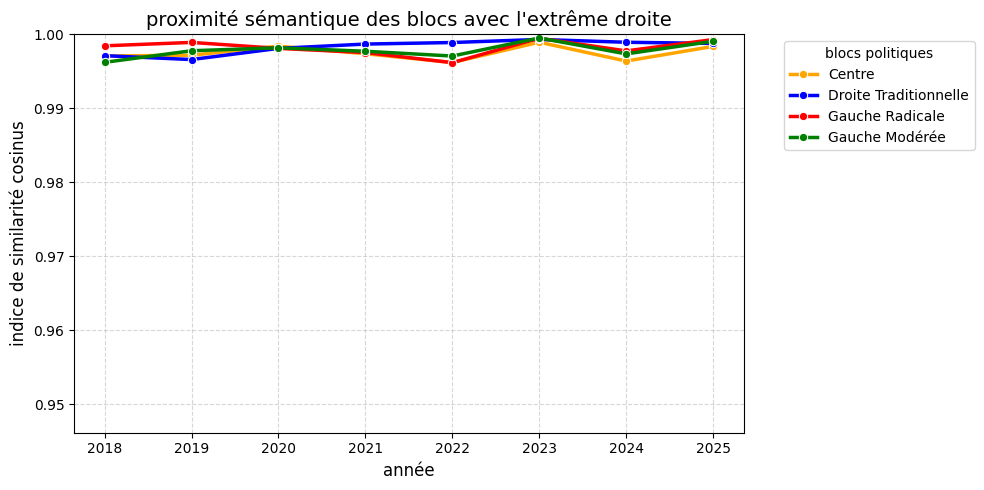


[9] Analyse du concept identitaire...


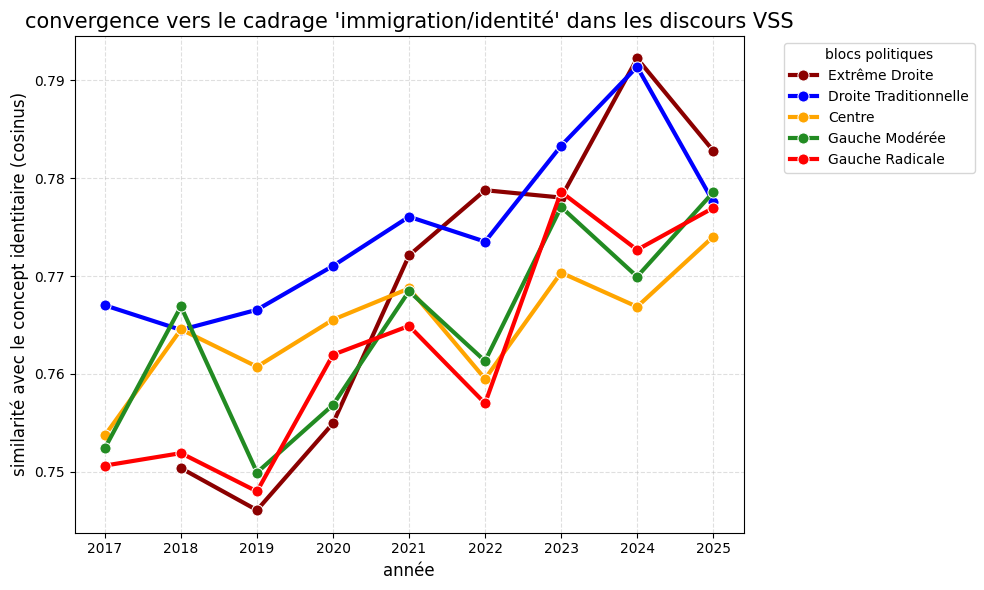


✅ Analyse terminée avec succès.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import os

# imports NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer

# imports gensim pour LDA et Word2Vec
from gensim import corpora, models
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# configuration
nltk.download('stopwords', quiet=True)
stemmer = FrenchStemmer()
stop_words_french = stopwords.words('french')

# mots-clés VSS (racines)
a_tester = [
    "viol", "sexis", "féminicide", "harcèl", "misogyn", 
    "sexuel", "machis", "égalité", "discrimin", "agress", "consent",
    "stéréotyp", "inégal", "domination", "patriarc", "genre", "quota",
    "lgbt", "transphobi", "homophobi", "non-binair", "mixité", "gynécolog",
    "avortement", "ivg", "contraception", "planning"
]

# ============================================================================
# PARTIE 1 : NORMALISATION DES STATISTIQUES
# ============================================================================

def calculer_stats_normalisees(df_global, df_vss):
    """
    Calcule les statistiques normalisées :
    - proportion de prises de parole VSS par parti
    - proportion de prises de parole VSS par période
    
    Arguments:
        df_global : DataFrame avec TOUTES les prises de parole
        df_vss : DataFrame avec UNIQUEMENT les prises de parole VSS
    
    Retourne:
        df_stats_partis : statistiques normalisées par parti
        df_stats_temps : statistiques normalisées par mois
    """
    
    # === NORMALISATION PAR PARTI ===
    # on compte le total de prises de parole par parti
    total_par_parti = df_global.groupby('nom_parti').size().reset_index(name='total_prises_parole')
    
    # on compte les prises de parole VSS par parti
    vss_par_parti = df_vss.groupby('nom_parti').size().reset_index(name='vss_prises_parole')
    
    # jointure et calcul de la proportion
    df_stats_partis = total_par_parti.merge(vss_par_parti, on='nom_parti', how='left')
    df_stats_partis['vss_prises_parole'] = df_stats_partis['vss_prises_parole'].fillna(0)
    df_stats_partis['proportion_vss'] = (
        df_stats_partis['vss_prises_parole'] / df_stats_partis['total_prises_parole'] * 100
    )
    
    # on trie par proportion décroissante
    df_stats_partis = df_stats_partis.sort_values('proportion_vss', ascending=False)
    
    # === NORMALISATION PAR PÉRIODE TEMPORELLE ===
    # on s'assure que la colonne date est au bon format
    df_global['date'] = pd.to_datetime(df_global['date'])
    df_vss['date'] = pd.to_datetime(df_vss['date'])
    
    # on crée une colonne année-mois
    df_global['periode'] = df_global['date'].dt.to_period('M')
    df_vss['periode'] = df_vss['date'].dt.to_period('M')
    
    # total de prises de parole par mois (toutes thématiques confondues)
    total_par_mois = df_global.groupby('periode').size().reset_index(name='total_prises_parole')
    
    # prises de parole VSS par mois
    vss_par_mois = df_vss.groupby('periode').size().reset_index(name='vss_prises_parole')
    
    # jointure et calcul de la proportion
    df_stats_temps = total_par_mois.merge(vss_par_mois, on='periode', how='left')
    df_stats_temps['vss_prises_parole'] = df_stats_temps['vss_prises_parole'].fillna(0)
    df_stats_temps['proportion_vss'] = (
        df_stats_temps['vss_prises_parole'] / df_stats_temps['total_prises_parole'] * 100
    )
    
    # conversion de la période en datetime pour les graphiques
    df_stats_temps['date'] = df_stats_temps['periode'].dt.to_timestamp()
    
    return df_stats_partis, df_stats_temps


def sauvegarder_documents_par_parti(df_vss, output_dir="/home/onyxia/work/projet_eco_socio/analyses_par_partis/"):
    """
    Sauvegarde les prises de parole VSS dans des fichiers texte par parti.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    for parti, group in df_vss.groupby("nom_parti"):
        # nettoyage du nom du parti pour le nom de fichier
        nom_propre = "".join(x for x in parti if x.isalnum() or x in "._- ").strip()
        
        with open(f"{output_dir}{nom_propre}.txt", "w", encoding="utf-8") as f:
            for discours in group["texte"]:
                f.write(discours + "\n\n---\n\n")
    
    print(f"Documents créés pour {len(df_vss['nom_parti'].unique())} partis.")


# ============================================================================
# PARTIE 2 : VISUALISATIONS NORMALISÉES
# ============================================================================

def tracer_top_partis_normalise(df_stats_partis, top_n=10):
    """
    Graphique en barres : proportion de prises de parole VSS par parti (Top N).
    """
    # on ne garde que les top N
    data_plot = df_stats_partis.head(top_n)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=data_plot, 
        x='proportion_vss', 
        y='nom_parti', 
        palette="viridis",
        hue='nom_parti',
        legend=False
    )
    plt.title(f"Top {top_n} des partis par proportion de prises de parole VSS", fontsize=14)
    plt.xlabel("pourcentage de prises de parole sur les VSS (%)", fontsize=12)
    plt.ylabel("parti politique", fontsize=12)
    
    # ajout des valeurs sur les barres
    for i, row in enumerate(data_plot.itertuples()):
        plt.text(
            row.proportion_vss + 0.1, 
            i, 
            f"{row.proportion_vss:.1f}% ({int(row.vss_prises_parole)}/{int(row.total_prises_parole)})",
            va='center',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.show()


def tracer_evolution_mensuelle_normalise(df_stats_temps):
    """
    Courbe : évolution mensuelle de la proportion de prises de parole VSS.
    """
    plt.figure(figsize=(14, 6))
    plt.plot(df_stats_temps['date'], df_stats_temps['proportion_vss'], 
             marker='o', color='teal', linewidth=2, markersize=4)
    
    plt.title("évolution de la proportion de débats consacrés aux VSS (2017-2025)", fontsize=14)
    plt.xlabel("temps", fontsize=12)
    plt.ylabel("pourcentage de prises de parole sur les VSS (%)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def tracer_heatmap_mots_cles(df_vss, a_tester, seuil_min=10):
    """
    Heatmap : répartition des mots-clés VSS par parti (normalisée ou brute).
    Note : cette visualisation reste en valeurs brutes car elle montre la 
    distribution des thématiques, pas le volume global.
    """
    # on crée une colonne pour chaque mot-clé
    for mot in a_tester:
        pattern = rf'\b{re.escape(mot.lower())}'
        df_vss[mot] = df_vss['texte'].str.contains(pattern, case=False, na=False, regex=True)
    
    # on regroupe par parti et on fait la somme des détections
    heatmap_data = df_vss.groupby('nom_parti')[a_tester].sum()
    
    # on ne garde que les partis avec un minimum de mentions
    heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > seuil_min]
    
    plt.figure(figsize=(16, 10))
    sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt='g', cbar_kws={'label': 'nombre de mentions'})
    plt.title("répartition des mots-clés VSS par parti politique", fontsize=14)
    plt.xlabel("mots-clés", fontsize=12)
    plt.ylabel("parti politique", fontsize=12)
    plt.tight_layout()
    plt.show()


# ============================================================================
# PARTIE 3 : ANALYSE SÉMANTIQUE (CADRAGE)
# ============================================================================

def analyser_cadrage_mot(df, mot_cible, stop_words):
    """
    Analyse les mots co-occurrents autour d'un concept clé.
    Fenêtre de ±10 mots.
    """
    resultats = {}
    
    for parti in df['nom_parti'].unique():
        if pd.isna(parti): 
            continue
            
        textes_parti = df[df['nom_parti'] == parti]['texte'].str.lower().tolist()
        mots_autour = []
        
        for t in textes_parti:
            segments = re.split(r'\W+', t)
            if mot_cible in segments:
                idx = segments.index(mot_cible)
                fenetre = segments[max(0, idx-10):idx] + segments[idx+1:idx+11]
                mots_autour.extend([m for m in fenetre if m not in stop_words and len(m) > 3])
        
        if mots_autour:
            top_mots = [m for m, c in Counter(mots_autour).most_common(5)]
            resultats[parti] = top_mots
            
    for parti, mots in resultats.items():
        print(f"🔍 autour de '{mot_cible}' chez {parti} : {', '.join(mots)}")


def enrichir_stopwords():
    """
    Enrichit la liste de stop words avec le bruit parlementaire.
    """
    mots_a_exclure = [
        "plus", "cette", "faire", "tout", "être", "bien", "comme", "aussi", 
        "fait", "tous", "entre", "leurs", "ceux", "celles", "sans", "dire",
        "ils", "elles", "sous", "vers", "notre", "votre", "leurs", "dont", "puis",
        "loi", "droit", "état", "amend", "articl", "text", "group", "cel", "autr", 
        "person", "social", "polit", "publi", "premier", "monsieur", 
        "madame", "président", "ministre", "député", "collègue", "assemblée",
        "proposit", "disposit", "cadre", "mesur", "moyen", "question", "rapport",
        "commission", "gouvern", "souhait", "permettr", "faut", "doit", "peut",
        "franc", "enfant", "depuis", "longtemps", "encore", "afin", "année"
    ]
    
    stop_words_french.extend(mots_a_exclure)
    return stop_words_french


# ============================================================================
# PARTIE 4 : AGRÉGATION TEMPORELLE ET TOPIC MODELING
# ============================================================================

def agreger_discours(df, granularite='Y'):
    """
    Agrège les textes par parti et période temporelle.
    granularite : 'Y' (année), 'M' (mois), 'Q' (trimestre)
    """
    df['date'] = pd.to_datetime(df['date'])
    df['periode'] = df['date'].dt.to_period(granularite).astype(str)
    
    df_docs = df.groupby(['nom_parti', 'periode'])['texte'].apply(lambda x: ' '.join(x)).reset_index()
    
    return df_docs


def pre_processing_recherche(texte, stop_words, mots_vss):
    """
    Nettoie le texte, stemme, et retire les mots-clés VSS pour éviter le biais.
    """
    # mise en minuscule et retrait de la ponctuation
    texte = re.sub(r'\W+', ' ', texte.lower())
    
    # tokenization
    mots = texte.split()
    
    # filtrage avec stemming
    mots_nettoyes = [
        stemmer.stem(m) for m in mots 
        if m not in stop_words 
        and not any(vss in m for vss in mots_vss)
        and len(m) > 2
    ]
    
    return " ".join(mots_nettoyes)


def preparer_corpus_lda(df_clean):
    """
    Transforme les textes au niveau de chaque prise de parole.
    """
    # On travaille directement sur df_vss (ou df_blocs au niveau discours)
    textes = [str(doc).split() for doc in df_clean['texte_clean'] if str(doc).strip() != ""]
    
    dictionnaire = corpora.Dictionary(textes)
    # Filtrage moins agressif pour capter les signaux faibles (identitaires)
    dictionnaire.filter_extremes(no_below=5, no_above=0.4)
    
    corpus = [dictionnaire.doc2bow(text) for text in textes]
    
    return dictionnaire, corpus


def entrainer_lda_final(corpus, dictionnaire, num_topics=5):
    """
    Entraîne le modèle LDA pour identifier les thématiques.
    """
    model = models.LdaModel(
        corpus=corpus, 
        id2word=dictionnaire, 
        num_topics=num_topics, 
        passes=20, 
        random_state=42
    )
    return model


def afficher_topics(lda_model):
    """
    Affiche les mots-clés de chaque topic découvert.
    """
    for i, topic in lda_model.print_topics(-1):
        print(f"thématique #{i}: {topic}")


def filtrer_docs_vides(df):
    """
    Supprime les lignes où le texte nettoyé est vide.
    """
    df_clean = df[df['texte_clean'].str.strip() != ""].copy()
    return df_clean


# ============================================================================
# PARTIE 5 : REGROUPEMENT EN BLOCS IDÉOLOGIQUES
# ============================================================================

def regrouper_blocs_ideologiques(nom_parti):
    """
    Associe chaque parti à un bloc idéologique.
    """
    nom = str(nom_parti).lower()
    
    # extrême droite
    if "rassemblement national" in nom or "front national" in nom or "udr" in nom:
        return "Extrême Droite"
    
    # droite traditionnelle
    if "républicains" in nom:
        return "Droite Traditionnelle"
    
    # centre (majorité présidentielle)
    centre = ["en marche", "république en marche", "renaissance", "ensemble", "modem", "mouvement démocrate", "horizons"]
    if any(c in nom for c in centre):
        return "Centre"
    
    # gauche modérée
    gauche_m = ["socialiste", "écologistes - eelv", "europe écologie les verts", "radical de gauche"]
    if any(g in nom for g in gauche_m):
        return "Gauche Modérée"
    
    # gauche radicale
    gauche_r = ["france insoumise", "communiste", "lfi"]
    if any(g in nom for g in gauche_r):
        return "Gauche Radicale"
    
    return None


# ============================================================================
# PARTIE 6 : ANALYSE DE CONVERGENCE (LDA)
# ============================================================================

def extraire_poids_topic_specifique(lda_model, corpus, df_original, target_topic):
    """
    Extrait le poids d'un topic pour chaque discours, puis on pourra moyenner par année.
    """
    poids_topic = []
    
    for bow in corpus:
        if not bow:
            poids_topic.append(0)
            continue
        distribution = lda_model.get_document_topics(bow)
        prob = dict(distribution).get(target_topic, 0)
        poids_topic.append(prob)
    
    df_res = df_original.copy()
    df_res['poids_identitaire'] = poids_topic
    
    # Agrégation a posteriori pour le graphique
    df_res['date'] = pd.to_datetime(df_res['date'])
    df_res['annee'] = df_res['date'].dt.to_period('Y').astype(str)
    
    # Moyenne du poids du topic par bloc et par an
    df_evolution = df_res.groupby(['annee', 'bloc'])['poids_identitaire'].mean().reset_index()
    return df_evolution


def tracer_convergence_lda(df, topic_name="identitaire"):
    """
    Compare l'évolution d'un topic entre blocs idéologiques.
    """
    ordre_blocs = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df, 
        x='annee', 
        y='poids_identitaire', 
        hue='bloc', 
        hue_order=ordre_blocs, 
        marker='o', 
        linewidth=2.5
    )
    
    plt.title(f"Poids du discours '{topic_name}' dans les débats VSS", fontsize=14)
    plt.ylabel(f"Probabilité du topic #{topic_name}", fontsize=12)
    plt.xlabel("Année", fontsize=12)
    plt.legend(title="Familles politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# ============================================================================
# PARTIE 7 : SIMILARITÉ COSINUS (WORD2VEC)
# ============================================================================

import torch
from transformers import CamembertTokenizer, CamembertModel
import numpy as np
from tqdm import tqdm

class CamembertEmbedding:
    def __init__(self, device=None):
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        
        self.tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
        self.model = CamembertModel.from_pretrained("camembert-base").to(self.device)
        self.model.eval()

    def encode(self, texte):
        inputs = self.tokenizer(
            str(texte),
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        # vecteur CLS (dimension 768)
        embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
        return embedding

def calculer_vecteur_moyen(texte, model):
    """
    Retourne le vecteur CamemBERT d'un texte.
    """
    if not texte or str(texte).strip() == "":
        return np.zeros(768)  # dimension camembert-base
    
    return model.encode(texte)
    

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def analyser_contagion_cosinus(df, model):
    """
    Compare chaque bloc à l'extrême droite année par année.
    Calcul des centroïdes au lieu de tronquer un texte géant.
    """
    # 1. Encodage de chaque discours individuellement (sur le texte BRUT, pas clean)
    # Tqdm pour voir l'avancement, car ça peut prendre un peu de temps
    tqdm.pandas(desc="Encodage CamemBERT")
    df['vecteur'] = df['texte'].progress_apply(lambda x: calculer_vecteur_moyen(x, model))
    
    # 2. Création de l'année
    df['date'] = pd.to_datetime(df['date'])
    df['annee'] = df['date'].dt.to_period('Y').astype(str)
    
    resultats = []
    
    for annee in sorted(df['annee'].unique()):
        df_an = df[df['annee'] == annee]
        
        if "Extrême Droite" in df_an['bloc'].values:
            # Calcul du centroïde (vecteur moyen) de l'Extrême Droite pour cette année
            vecteurs_ed = np.vstack(df_an[df_an['bloc'] == "Extrême Droite"]['vecteur'].values)
            centroid_ed = np.mean(vecteurs_ed, axis=0)
            
            for bloc in df_an['bloc'].unique():
                if bloc == "Extrême Droite":
                    continue
                
                # Centroïde du bloc cible
                vecteurs_cible = np.vstack(df_an[df_an['bloc'] == bloc]['vecteur'].values)
                centroid_cible = np.mean(vecteurs_cible, axis=0)
                
                sim = cosine_similarity([centroid_ed], [centroid_cible])[0][0]
                
                resultats.append({
                    'annee': annee,
                    'bloc': bloc,
                    'similarite': sim
                })
    
    return pd.DataFrame(resultats)

def tracer_graphique_similarite(df):
    """
    Graphique de proximité sémantique avec l'extrême droite.
    """
    if df.empty:
        print("le tableau de similarité est vide.")
        return

    plt.figure(figsize=(10, 5))
    
    palette_couleurs = {
        "Droite Traditionnelle": "blue",
        "Centre": "orange",
        "Gauche Modérée": "green",
        "Gauche Radicale": "red"
    }

    sns.lineplot(
        data=df, 
        x='annee', 
        y='similarite', 
        hue='bloc', 
        palette=palette_couleurs, 
        marker='o', 
        linewidth=2.5
    )

    plt.title("proximité sémantique des blocs avec l'extrême droite", fontsize=14)
    plt.ylabel("indice de similarité cosinus", fontsize=12)
    plt.xlabel("année", fontsize=12)
    plt.legend(title="blocs politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(df['similarite'].min() - 0.05, 1.0)
    plt.tight_layout()
    plt.show()


# ============================================================================
# PARTIE 8 : ANALYSE CIBLÉE (CONCEPT IDENTITAIRE)
# ============================================================================

def creer_vecteur_concept(model, mots_clefs):
    """
    Crée un vecteur conceptuel via CamemBERT
    en encodant les mots clés ensemble.
    """
    phrase = " ".join(mots_clefs)
    return model.encode(phrase)

def filtrage_strict_intersection(df, liste_vss, liste_identitaire):
    """
    Ne garde que les paragraphes où VSS ET identité se croisent.
    """
    pattern_vss = '|'.join(liste_vss)
    pattern_id = '|'.join(liste_identitaire)
    
    mask = (df['texte'].str.contains(pattern_vss, case=False, na=False)) & \
           (df['texte'].str.contains(pattern_id, case=False, na=False))
    
    return df[mask].copy()


def mesurer_derive_vers_concept(df, model, vecteur_ref):
    """
    Similarité moyenne de chaque bloc par rapport au concept identitaire.
    """
    df['date'] = pd.to_datetime(df['date'])
    df['annee'] = df['date'].dt.to_period('Y').astype(str)
    
    # Distance de chaque discours au vecteur concept
    df['proximite_identitaire'] = df['vecteur'].apply(
        lambda x: cosine_similarity([x], [vecteur_ref])[0][0]
    )
    
    # Moyenne par bloc et par an
    df_derive = df.groupby(['annee', 'bloc'])['proximite_identitaire'].mean().reset_index()
    return df_derive

def tracer_derive_concept_identitaire(df):
    """
    Graphique de convergence vers le concept immigration/identité.
    """
    df = df.sort_values('annee')
    
    plt.figure(figsize=(10, 6))
    
    couleurs = {
        "Extrême Droite": "#8B0000",
        "Droite Traditionnelle": "#0000FF",
        "Centre": "#FFA500",
        "Gauche Modérée": "#228B22",
        "Gauche Radicale": "#FF0000"
    }
    
    ordre = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

    sns.lineplot(
        data=df, 
        x='annee', 
        y='proximite_identitaire', 
        hue='bloc', 
        hue_order=ordre, 
        palette=couleurs, 
        marker='o', 
        linewidth=3, 
        markersize=8
    )

    plt.title("convergence vers le cadrage 'immigration/identité' dans les discours VSS", fontsize=15)
    plt.ylabel("similarité avec le concept identitaire (cosinus)", fontsize=12)
    plt.xlabel("année", fontsize=12)
    plt.legend(title="blocs politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    """
    PIPELINE D'ANALYSE VSS AVEC CAMEMBERT
    """

    print("="*80)
    print("PIPELINE D'ANALYSE VSS – VERSION CAMEMBERT")
    print("="*80)

    # === CHARGEMENT DES DONNÉES ===
    # df_global = pd.read_pickle("df_global")
    # df_vss = pd.read_pickle("df_vss")

    # ============================================================
    # 1️⃣ STATISTIQUES NORMALISÉES
    # ============================================================

    print("\n[1] Calcul des statistiques normalisées...")
    df_stats_partis, df_stats_temps = calculer_stats_normalisees(df_global, df_vss)

    # ============================================================
    # 2️⃣ VISUALISATIONS
    # ============================================================

    print("\n[2] Génération des graphiques normalisés...")
    tracer_top_partis_normalise(df_stats_partis, top_n=43)
    tracer_evolution_mensuelle_normalise(df_stats_temps)
    tracer_heatmap_mots_cles(df_vss, a_tester)

    # ============================================================
    # 3️⃣ ANALYSE DE CADRAGE
    # ============================================================

    print("\n[3] Analyse du cadrage sémantique...")
    stop_words_enrichis = enrichir_stopwords()
    analyser_cadrage_mot(df_vss, "féminicide", stop_words_enrichis)

    # ============================================================
    # 4️⃣ NETTOYAGE (SANS AGRÉGATION)
    # ============================================================

    print("\n[4] Nettoyage des textes individuels...")
    # On travaille directement sur df_vss
    df_vss['texte_clean'] = df_vss['texte'].apply(
        lambda x: pre_processing_recherche(x, stop_words_enrichis, a_tester)
    )

    df_vss = filtrer_docs_vides(df_vss)

    # ============================================================
    # 5️⃣ BLOCS IDÉOLOGIQUES
    # ============================================================

    print("\n[5] Création des blocs idéologiques...")
    df_vss['bloc'] = df_vss['nom_parti'].apply(regrouper_blocs_ideologiques)
    
    df_blocs = df_vss.dropna(subset=['bloc']).copy()

    # ============================================================
    # 6️⃣ LDA (AU NIVEAU DES DISCOURS)
    # ============================================================

    print("\n[6] Entraînement du modèle LDA (15 thématiques)...")
    dictionnaire, corpus = preparer_corpus_lda(df_blocs)
    
    # On force num_topics=15 ici 
    lda = entrainer_lda_final(corpus, dictionnaire, num_topics=15)
    afficher_topics(lda)

    # ============================================================
    # 7️⃣ ANALYSE LDA
    # ============================================================

    topic_identitaire = 11 

    print(f"\n[7] Extraction des poids pour le topic #{topic_identitaire}...")
    df_evolution = extraire_poids_topic_specifique(
        lda, corpus, df_blocs, target_topic=topic_identitaire
    )

    tracer_convergence_lda(df_evolution, topic_name="identitaire")

    # ============================================================
    # 8️⃣ CAMEMBERT – SIMILARITÉ ENTRE BLOCS
    # ============================================================

    print("\n[8] Chargement de CamemBERT...")
    model_camembert = CamembertEmbedding()

    print("Encodage des prises de parole individuelles (ça va prendre un peu de temps)...")
    # On passe le df_blocs brut, la fonction modifiée va calculer les centroïdes
    df_sim = analyser_contagion_cosinus(df_blocs, model_camembert)
    tracer_graphique_similarite(df_sim)

    # ============================================================
    # 9️⃣ CONCEPT CIBLÉ – IMMIGRATION / IDENTITÉ
    # ============================================================

    print("\n[9] Analyse du concept identitaire...")

    mots_identitaires = [
        "immigration", "clandestin", "frontière",
        "national", "identité", "culture",
        "étranger", "expulsion", "valeurs"
    ]

    vecteur_ref = creer_vecteur_concept(model_camembert, mots_identitaires)

 
    df_derive = mesurer_derive_vers_concept(
        df_blocs,
        model_camembert,
        vecteur_ref
    )

    tracer_derive_concept_identitaire(df_derive)

    print("\n✅ Analyse terminée avec succès.")
    
  